# EDA — Bộ dữ liệu Cuộc thi Toán Mô Hình 2026 (Bảng B)

Notebook này khám phá bộ dữ liệu `locations.csv` và `time_windows.csv` trước khi
thiết kế thuật toán lập lịch giao hàng. Mục tiêu của EDA ở đây không chỉ là "vẽ cho
đẹp" mà là trả lời các câu hỏi sẽ ảnh hưởng trực tiếp đến thiết kế thuật toán:

- Khách hàng phân bố trong không gian như thế nào? (đều hay tụ cụm quanh kho?)
- Time window "dễ" hay "khó" — có bao nhiêu window/ngày, dài hay ngắn?
- Có nhóm khách hàng nào **cấu trúc khó giao** rõ rệt không (ít ngày có window,
  window ngắn) — đây thường chính là nhóm gây ra các đơn hàng không hoàn thành.

**Cấu trúc notebook:**
1. Tổng quan & thống kê mô tả
2. Phân bố không gian (toạ độ khách hàng)
3. Phân bố nhu cầu (demand) & thời gian phục vụ
4. Phân bố time window theo ngày / theo giờ / theo độ dài
5. "Độ khó" của từng khách hàng — chuẩn bị insight cho thuật toán


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

LOCATIONS_PATH = Path("locations.csv")
TIME_WINDOWS_PATH = Path("time_windows.csv")

for p in (LOCATIONS_PATH, TIME_WINDOWS_PATH):
    if not p.exists():
        raise FileNotFoundError(
            f"Không tìm thấy {p}. Hãy đặt locations.csv và time_windows.csv "
            f"cùng thư mục với notebook này."
        )

locations = pd.read_csv(LOCATIONS_PATH)
time_windows = pd.read_csv(TIME_WINDOWS_PATH)

print("locations.csv  ->", locations.shape)
print("time_windows.csv ->", time_windows.shape)
locations.head()


locations.csv  -> (301, 6)
time_windows.csv -> (1359, 4)


,location_id,location_name,x_km,y_km,demand_kg,service_time
0,DEPOT,Kho_Trung_Tam,0.0000,0.0000,0.0,0
1,C001,Khach_Hang_001,-11.7188,-9.1881,0.6,5
2,C002,Khach_Hang_002,9.7173,11.6111,0.6,5
3,C003,Khach_Hang_003,6.9787,10.1386,2.4,7
4,C004,Khach_Hang_004,-18.5445,8.8454,3.9,5


In [2]:
time_windows.head()


,location_id,day_of_week,start_time,end_time
0,C001,2,18:30,21:30
1,C001,3,18:30,21:30
2,C001,4,18:30,21:30
3,C001,5,18:30,21:30
4,C001,7,08:00,21:00


## 1. Tổng quan & thống kê mô tả

Trước khi vẽ bất kỳ biểu đồ nào, luôn kiểm tra 3 điều cơ bản: kiểu dữ liệu có đúng
không, có thiếu dữ liệu (missing) không, và các con số thống kê mô tả có "hợp lý"
không (ví dụ: demand âm là dấu hiệu lỗi dữ liệu).


In [3]:
print("=== dtypes: locations ===")
print(locations.dtypes)
print()
print("=== dtypes: time_windows ===")
print(time_windows.dtypes)


=== dtypes: locations ===
location_id          str
location_name        str
x_km             float64
y_km             float64
demand_kg        float64
service_time       int64
dtype: object

=== dtypes: time_windows ===
location_id      str
day_of_week    int64
start_time       str
end_time         str
dtype: object


In [4]:
print("Missing values - locations:")
print(locations.isna().sum())
print()
print("Missing values - time_windows:")
print(time_windows.isna().sum())


Missing values - locations:
location_id      0
location_name    0
x_km             0
y_km             0
demand_kg        0
service_time     0
dtype: int64

Missing values - time_windows:
location_id    0
day_of_week    0
start_time     0
end_time       0
dtype: int64


In [5]:
# Tách riêng depot (kho) và khách hàng, vì depot có demand=0, service_time=0
# nên gộp chung vào thống kê mô tả sẽ làm lệch kết quả (ví dụ min demand luôn = 0).
depot = locations[locations["location_id"] == "DEPOT"].iloc[0]
customers = locations[locations["location_id"] != "DEPOT"].copy()

print("Depot:", depot["location_name"], f"tại ({depot['x_km']}, {depot['y_km']})")
print("Số khách hàng:", len(customers))
customers[["x_km", "y_km", "demand_kg", "service_time"]].describe()


Depot: Kho_Trung_Tam tại (0.0, 0.0)
Số khách hàng: 300


,x_km,y_km,demand_kg,service_time
count,300.000000,300.000000,300.000000,300.000000
mean,-5.977808,1.641516,2.729000,7.420000
std,11.920108,9.987342,1.246879,2.073144
min,-22.918700,-21.160300,0.600000,5.000000
25%,-16.537350,-9.074150,1.700000,5.000000
50%,-10.639950,5.409900,2.800000,7.000000
75%,6.667550,9.644400,3.700000,10.000000
max,20.047900,21.820100,5.000000,10.000000


**Nhận xét nhanh:** demand dao động trong khoảng nhỏ, không có giá trị âm hay bất
thường — dữ liệu sạch. `service_time` là biến rời rạc (không phải liên tục), nên ở
phần sau ta sẽ dùng `countplot` thay vì `histplot` cho biến này.


## 2. Phân bố không gian

Câu hỏi: khách hàng có tụ quanh kho (dễ giao, quãng đường ngắn) hay rải rác xa
(khó giao, tốn nhiều thời gian di chuyển)? Vì xe giới hạn tốc độ 50km/h, khoảng
cách xa đồng nghĩa với thời gian di chuyển lớn — ảnh hưởng trực tiếp đến số đơn
có thể giao trong một ngày.


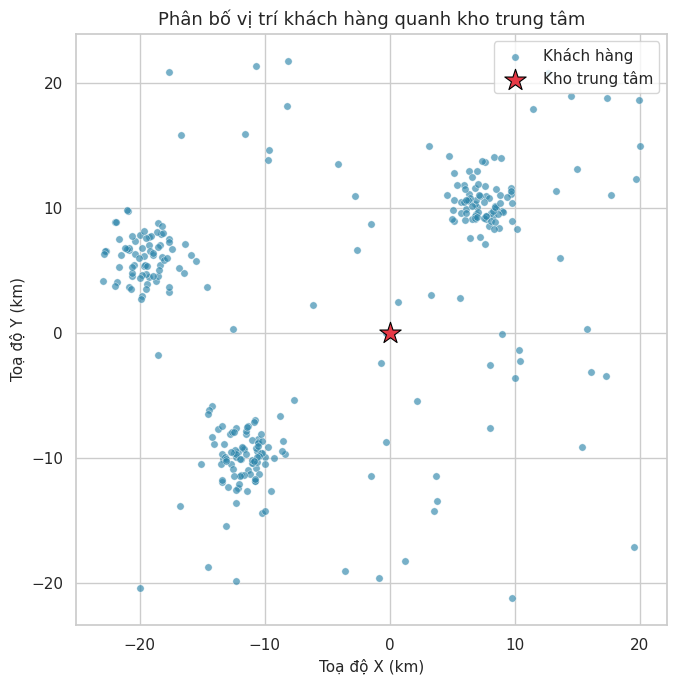

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(customers["x_km"], customers["y_km"], s=28, alpha=0.65,
           color="#2E86AB", edgecolor="white", linewidth=0.4, label="Khách hàng")
ax.scatter([depot["x_km"]], [depot["y_km"]], s=260, marker="*",
           color="#E63946", edgecolor="black", linewidth=0.8, zorder=5, label="Kho trung tâm")

ax.set_xlabel("Toạ độ X (km)")
ax.set_ylabel("Toạ độ Y (km)")
ax.set_title("Phân bố vị trí khách hàng quanh kho trung tâm")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


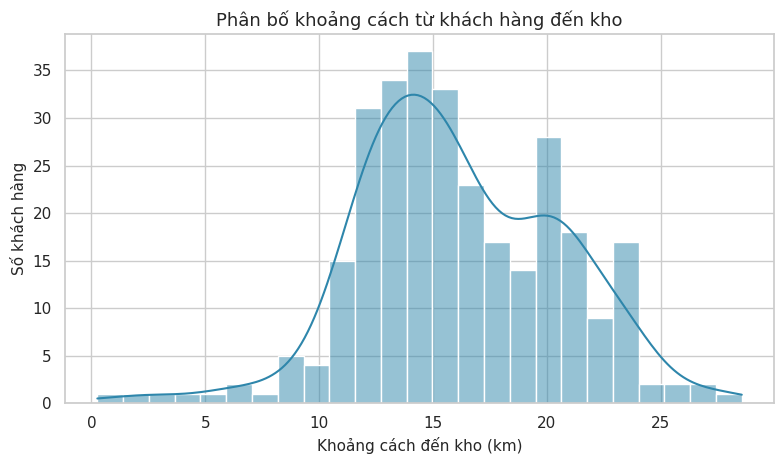

count    300.000000
mean      16.120229
std        4.434226
min        0.258754
25%       13.140077
50%       15.609265
75%       19.770512
max       28.555292
Name: dist_to_depot_km, dtype: float64


In [7]:
# Khoảng cách Euclid từ mỗi khách hàng đến kho -- biến này sẽ dùng lại nhiều lần
customers["dist_to_depot_km"] = np.hypot(
    customers["x_km"] - depot["x_km"], customers["y_km"] - depot["y_km"]
)

fig, ax = plt.subplots()
sns.histplot(customers["dist_to_depot_km"], bins=25, kde=True, color="#2E86AB", ax=ax)
ax.set_xlabel("Khoảng cách đến kho (km)")
ax.set_ylabel("Số khách hàng")
ax.set_title("Phân bố khoảng cách từ khách hàng đến kho")
plt.tight_layout()
plt.show()

print(customers["dist_to_depot_km"].describe())


**Ý nghĩa cho thuật toán:** nếu phân bố này lệch phải nhiều (nhiều khách ở rất xa),
một chiến lược "luôn ghé gần nhất trước" (Nearest-Neighbor) sẽ dễ "bỏ quên" các
khách ở xa đến cuối ngày, làm tăng nguy cơ họ bị lỡ time window buổi tối.


## 3. Phân bố nhu cầu (demand) và thời gian phục vụ

Đề bài không yêu cầu kiểm tra tải trọng xe, nhưng hiểu phân bố `demand_kg` vẫn hữu
ích nếu muốn mở rộng mô hình sau này (ràng buộc sức chứa xe). `service_time` chỉ
nhận 3 giá trị rời rạc nên ta dùng biểu đồ cột thay vì histogram.


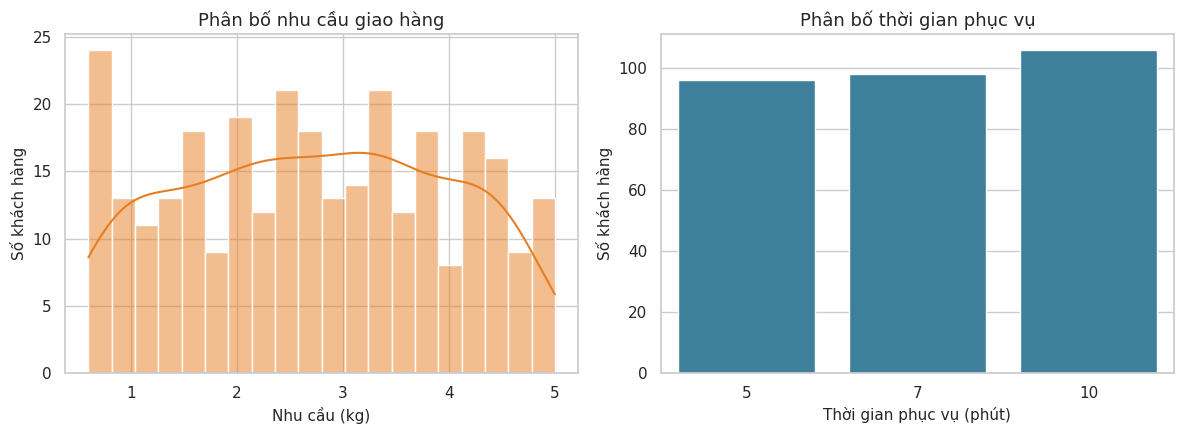

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(customers["demand_kg"], bins=20, kde=True, color="#E67E22", ax=axes[0])
axes[0].set_xlabel("Nhu cầu (kg)")
axes[0].set_ylabel("Số khách hàng")
axes[0].set_title("Phân bố nhu cầu giao hàng")

order = sorted(customers["service_time"].unique())
sns.countplot(x="service_time", data=customers, order=order, color="#2E86AB", ax=axes[1])
axes[1].set_xlabel("Thời gian phục vụ (phút)")
axes[1].set_ylabel("Số khách hàng")
axes[1].set_title("Phân bố thời gian phục vụ")

plt.tight_layout()
plt.show()


In [9]:
total_demand = customers["demand_kg"].sum()
print(f"Tổng nhu cầu cả tuần: {total_demand:.1f} kg")
print(f"Nhu cầu trung bình/khách: {customers['demand_kg'].mean():.2f} kg")
print()
print("Tỉ lệ mỗi mức service_time:")
print(customers["service_time"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


Tổng nhu cầu cả tuần: 818.7 kg
Nhu cầu trung bình/khách: 2.73 kg

Tỉ lệ mỗi mức service_time:
service_time
10    35.3%
7     32.7%
5     32.0%
Name: proportion, dtype: str


## 4. Phân bố time window

Đây là phần quan trọng nhất — độ khó thật sự của bài toán nằm ở đây, không phải ở
toạ độ. Ta cần trả lời: window xuất hiện nhiều/ít vào ngày nào, giờ nào trong ngày,
và window dài hay ngắn.

Trước tiên, quy đổi `start_time`/`end_time` (dạng chuỗi "HH:MM") sang phút trong
ngày để dễ tính toán và vẽ biểu đồ.


In [10]:
def to_minutes(hhmm: str) -> int:
    h, m = hhmm.split(":")
    return int(h) * 60 + int(m)

tw = time_windows.copy()
tw["start_min"] = tw["start_time"].apply(to_minutes)
tw["end_min"] = tw["end_time"].apply(to_minutes)
tw["duration_min"] = tw["end_min"] - tw["start_min"]

day_names = {1: "T2", 2: "T3", 3: "T4", 4: "T5", 5: "T6", 6: "T7", 7: "CN"}
tw["day_name"] = tw["day_of_week"].map(day_names)

tw.head()


,location_id,day_of_week,start_time,end_time,start_min,end_min,duration_min,day_name
0,C001,2,18:30,21:30,1110,1290,180,T3
1,C001,3,18:30,21:30,1110,1290,180,T4
2,C001,4,18:30,21:30,1110,1290,180,T5
3,C001,5,18:30,21:30,1110,1290,180,T6
4,C001,7,08:00,21:00,480,1260,780,CN


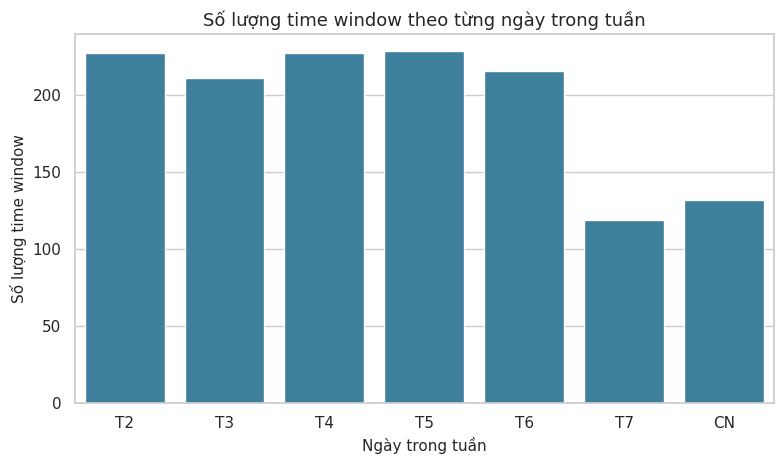

In [11]:
fig, ax = plt.subplots()
order = [day_names[d] for d in range(1, 8)]
sns.countplot(x="day_name", data=tw, order=order, color="#2E86AB", ax=ax)
ax.set_xlabel("Ngày trong tuần")
ax.set_ylabel("Số lượng time window")
ax.set_title("Số lượng time window theo từng ngày trong tuần")
plt.tight_layout()
plt.show()


**Nhận xét:** nếu các ngày cuối tuần (T7, CN) có ít window hơn hẳn ngày thường, đó
là dấu hiệu cuối tuần "khó giao" hơn — hợp lý vì đề bài mô tả cuối tuần khách có
thể nhận hàng "bất kỳ lúc nào" (ít ràng buộc hơn) NHƯNG một số khách có thể hoàn
toàn không có window cuối tuần (không muốn nhận hàng ngày nghỉ).


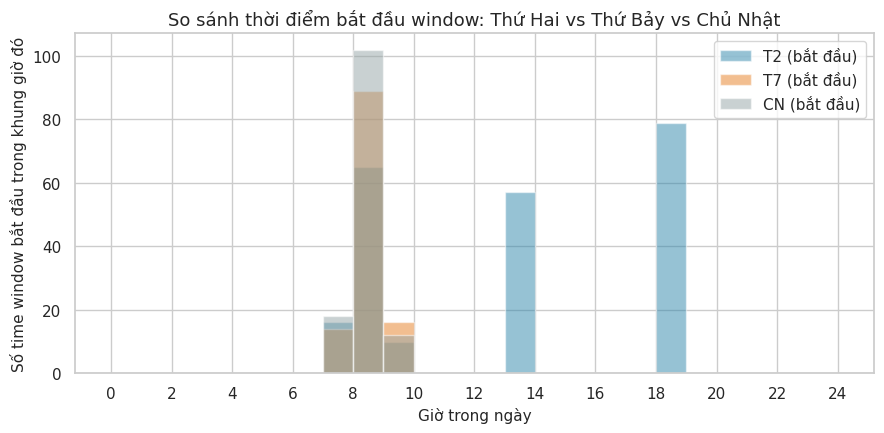

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# Vẽ mỗi time window như một đoạn ngang (Gantt-style) để thấy rõ khung giờ thực tế
sample_days = [1, 6, 7]  # Thứ Hai, Thứ Bảy, Chủ Nhật để so sánh ngày thường vs cuối tuần
colors = {1: "#2E86AB", 6: "#E67E22", 7: "#95A5A6"}

for d in sample_days:
    subset = tw[tw["day_of_week"] == d]
    ax.hist(subset["start_min"] / 60, bins=24, range=(0, 24), alpha=0.5,
            label=f"{day_names[d]} (bắt đầu)", color=colors[d])

ax.set_xlabel("Giờ trong ngày")
ax.set_ylabel("Số time window bắt đầu trong khung giờ đó")
ax.set_title("So sánh thời điểm bắt đầu window: Thứ Hai vs Thứ Bảy vs Chủ Nhật")
ax.set_xticks(range(0, 25, 2))
ax.legend()
plt.tight_layout()
plt.show()


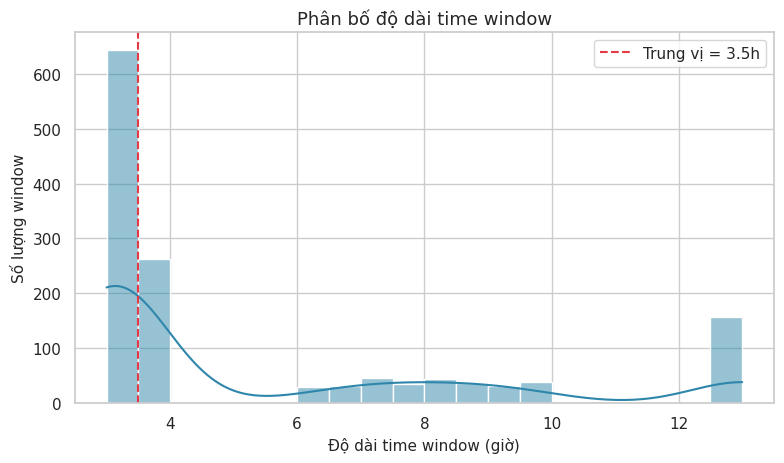

count    22.650000
mean      5.349191
std       3.449026
min       3.000000
25%       3.000000
50%       3.500000
75%       7.575000
max      13.000000
Name: duration_min, dtype: float64


In [13]:
fig, ax = plt.subplots()
sns.histplot(tw["duration_min"] / 60, bins=20, kde=True, color="#2E86AB", ax=ax)
ax.set_xlabel("Độ dài time window (giờ)")
ax.set_ylabel("Số lượng window")
ax.set_title("Phân bố độ dài time window")
ax.axvline(tw["duration_min"].median() / 60, color="#E63946", linestyle="--",
           label=f"Trung vị = {tw['duration_min'].median()/60:.1f}h")
ax.legend()
plt.tight_layout()
plt.show()

print(tw["duration_min"].describe() / 60)  # đổi ra giờ cho dễ đọc


**Ý nghĩa cho thuật toán:** độ lệch chuẩn của độ dài window khá lớn — nghĩa là có
cả window rất ngắn (khó giao, dễ bị lỡ) lẫn window rất dài (dễ giao, linh hoạt).
Đây chính là lý do thuật toán cần một cơ chế ưu tiên (như EDF) thay vì xử lý ngẫu
nhiên hoặc chỉ theo khoảng cách.


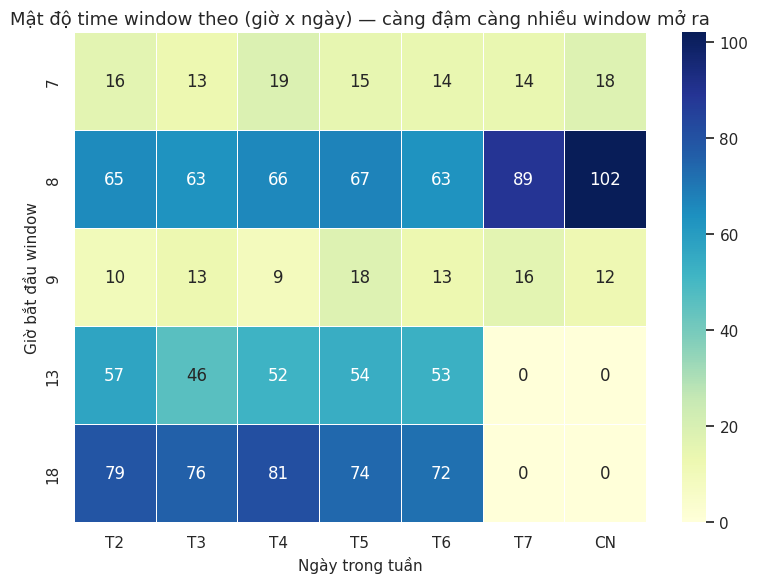

In [14]:
# Heatmap: mật độ time window theo (ngày x giờ) -- cho thấy "giờ cao điểm" của cả tuần
tw["start_hour"] = (tw["start_min"] // 60).clip(0, 23)

pivot = tw.pivot_table(
    index="start_hour", columns="day_name", values="location_id",
    aggfunc="count", fill_value=0
)
pivot = pivot[[day_names[d] for d in range(1, 8)]]  # sắp lại đúng thứ tự T2->CN

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.5, ax=ax)
ax.set_xlabel("Ngày trong tuần")
ax.set_ylabel("Giờ bắt đầu window")
ax.set_title("Mật độ time window theo (giờ x ngày) — càng đậm càng nhiều window mở ra")
plt.tight_layout()
plt.show()


## 5. "Độ khó" của từng khách hàng

Đây là bước quan trọng nhất để chuẩn bị cho phần thiết kế thuật toán: xác định
trước nhóm khách hàng có cấu trúc time window "khó" — ít ngày có window, window
ngắn — vì đây thường chính là nhóm dễ trở thành đơn hàng không hoàn thành.


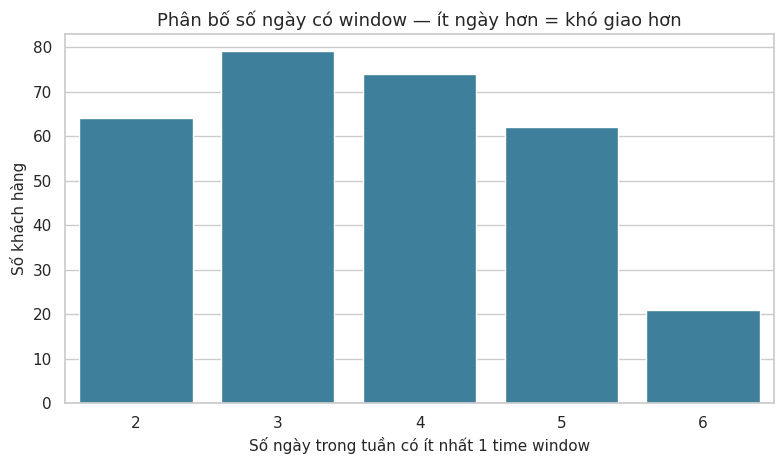

Khách hàng chỉ có window đúng 2 ngày/tuần (nhóm khó nhất): 64


In [15]:
days_per_customer = tw.groupby("location_id")["day_of_week"].nunique().rename("n_days_with_window")
min_duration_per_customer = tw.groupby("location_id")["duration_min"].min().rename("min_window_duration")

difficulty = pd.concat([days_per_customer, min_duration_per_customer], axis=1).reset_index()
difficulty = difficulty.rename(columns={"index": "location_id"})

fig, ax = plt.subplots()
sns.countplot(x="n_days_with_window", data=difficulty, color="#2E86AB", ax=ax)
ax.set_xlabel("Số ngày trong tuần có ít nhất 1 time window")
ax.set_ylabel("Số khách hàng")
ax.set_title("Phân bố số ngày có window — ít ngày hơn = khó giao hơn")
plt.tight_layout()
plt.show()

print("Khách hàng chỉ có window đúng 2 ngày/tuần (nhóm khó nhất):", (difficulty["n_days_with_window"] == 2).sum())


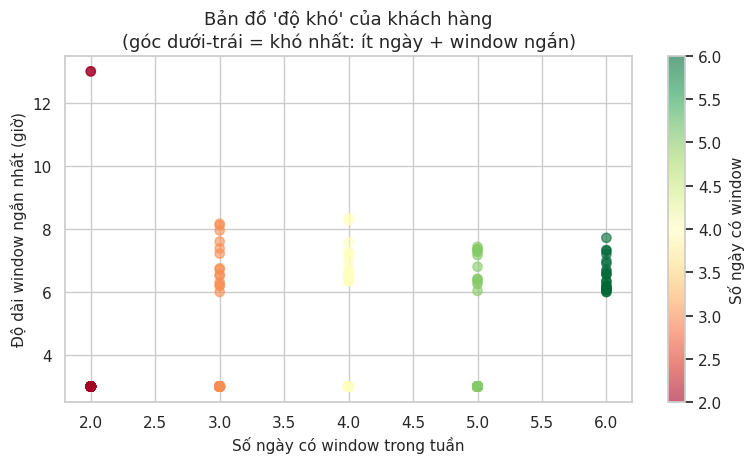

In [16]:
fig, ax = plt.subplots()
sc = ax.scatter(
    difficulty["n_days_with_window"], difficulty["min_window_duration"] / 60,
    s=45, alpha=0.6, c=difficulty["n_days_with_window"], cmap="RdYlGn"
)
ax.set_xlabel("Số ngày có window trong tuần")
ax.set_ylabel("Độ dài window ngắn nhất (giờ)")
ax.set_title("Bản đồ 'độ khó' của khách hàng\n(góc dưới-trái = khó nhất: ít ngày + window ngắn)")
plt.colorbar(sc, label="Số ngày có window")
plt.tight_layout()
plt.show()


In [17]:
# Nhóm "khó nhất": ít ngày có window NHẤT và window ngắn nhất
hardest = difficulty.sort_values(["n_days_with_window", "min_window_duration"]).head(15)
hardest = hardest.merge(customers[["location_id", "location_name", "demand_kg"]], on="location_id")
hardest["min_window_duration_h"] = (hardest["min_window_duration"] / 60).round(1)
hardest[["location_id", "location_name", "n_days_with_window", "min_window_duration_h", "demand_kg"]]


,location_id,location_name,n_days_with_window,min_window_duration_h,demand_kg
0,C002,Khach_Hang_002,2,3.0,0.6
1,C008,Khach_Hang_008,2,3.0,4.2
2,C014,Khach_Hang_014,2,3.0,1.7
3,C016,Khach_Hang_016,2,3.0,0.8
4,C019,Khach_Hang_019,2,3.0,2.4
5,C023,Khach_Hang_023,2,3.0,4.4
6,C029,Khach_Hang_029,2,3.0,3.2
7,C036,Khach_Hang_036,2,3.0,2.8
8,C039,Khach_Hang_039,2,3.0,4.4
9,C040,Khach_Hang_040,2,3.0,2.7


**Liên hệ với kết quả thuật toán:** nhóm khách hàng "khó nhất" xác định ở đây (ít
ngày có window, window ngắn — thường là các window buổi tối 3 tiếng, chỉ xuất
hiện 2 ngày/tuần) chính là ứng viên hàng đầu cho các đơn hàng **không hoàn
thành** khi chạy thuật toán lập lịch thực tế. Biết trước nhóm này giúp:
1. Diễn giải kết quả thuật toán một cách có cơ sở dữ liệu, thay vì chỉ nhìn con số cuối.
2. Nếu muốn cải thiện completion rate, đây chính là nhóm cần được ưu tiên xử lý sớm nhất trong tuần.


## 6. Tổng kết EDA — những gì cần mang sang bước thiết kế thuật toán

| Phát hiện | Ảnh hưởng đến thiết kế thuật toán |
|---|---|
| Khách hàng phân bố ra sao quanh kho (xem mục 2) | Quyết định chiến lược "gần nhất trước" có đủ tốt hay cần nhìn xa hơn (time window) |
| Demand khá đồng đều, không có outlier | Có thể tạm bỏ qua ràng buộc tải trọng như đề bài cho phép |
| Time window ngày thường vs cuối tuần khác biệt rõ rệt | Cần xử lý ngày trong tuần như một trục ưu tiên riêng, không gộp chung |
| Độ dài window có phương sai lớn | Cần cơ chế ưu tiên theo "độ khẩn cấp" (kiểu EDF) thay vì random/FIFO |
| Có một nhóm nhỏ khách hàng "khó" rõ rệt (ít ngày, window ngắn) | Nhóm này gần như chắc chắn là nguồn gốc chính của các đơn không hoàn thành — cần xử lý sớm trong tuần, không để dồn cuối |

Notebook tiếp theo (thiết kế & chạy thuật toán) sẽ dùng lại các quan sát này để
giải thích *tại sao* thuật toán được thiết kế theo hướng ưu tiên liên-ngày (EDF)
thay vì các baseline đơn giản hơn.
